# Setup

In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(ggplot2)
    library(eulerr)
})

In [2]:
# FOR NONO
NONO_INf_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R/tables/differential_windows.tsv",
                    sep = "\t")
NONO_INg_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R_INg/tables/differential_windows.tsv",
                    sep = "\t")
NONO_INf_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R/tables/all_windows.tsv",
                   sep = "\t")
NONO_INg_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R_INg/tables/all_windows.tsv",
                    sep = "\t")

# For DDX42
DDX42_INf_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active/tables/differential_windows.tsv",
                    sep = "\t")
DDX42_INg_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active_INg/tables/differential_windows.tsv",
                    sep = "\t")
DDX42_INf_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active/tables/all_windows.tsv",
                   sep = "\t")
DDX42_INg_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active_INg/tables/all_windows.tsv",
                    sep = "\t")

# For PUF60
PUF60_INf_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/PUF60/tables/differential_windows.tsv",
                    sep = "\t")
PUF60_INg_sigs = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/PUF60_INg/tables/differential_windows.tsv",
                    sep = "\t")
PUF60_INf_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/PUF60/tables/all_windows.tsv",
                   sep = "\t")
PUF60_INg_all = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/PUF60_INg/tables/all_windows.tsv",
                    sep = "\t")


# Helper functions

In [3]:
make_venn = function(INf_sigs, INg_sigs, save_path) {

    # Extract out all unique IDs for the INf and INg runs. 
    INf_ids = unique(paste(INf_sigs$chr, INf_sigs$start, INf_sigs$end, sep = ":"))
    INg_ids = unique(paste(INg_sigs$chr, INg_sigs$start, INg_sigs$end, sep = ":"))

    # Fit to a euler diagram (venn diagram). 
    fit = eulerr::euler(list(INf = INf_ids, INg = INg_ids))

    # Plot the euler fit. 
    p = plot(fit, fills = list(fill = c("steelblue", "tomato"), alpha = 0.5),
              quantities = list(cex = 2, font = 2, col = "black"),
              labels = list(cex = 2.5, font = 2, family = "sans", col = "black"),
              edges = list(lwd = 2))

    # Create the plot and save. (must save differently since it is not ggplot. )
    grid::grid.draw(p)
    svglite::svglite(save_path, width = 6, height = 5)
    grid::grid.draw(p)
    dev.off()
}

In [4]:
make_hist = function(INf_all, INg_sigs) {

    # Select just the values of interest to plot. 
    INf_to_plot = dplyr::select(INf_all, c("chr", "start", "end", "log2FoldChange"))
    INg_to_plot = dplyr::select(INg_sigs, c("chr", "start", "end", "log2FoldChange"))

    # Using a left-join so that we can see the INf values for all INg hits. 
    compare_IN = left_join(INg_to_plot, INf_to_plot, by = join_by(chr, start, end), suffix = c("_INg", "_INf"))

    # Create the histogram. 
    g = ggplot(compare_IN, aes(x = log2FoldChange_INf)) +
        geom_histogram(bins = 100,fill = "steelblue",color = "black",linewidth = 0.2) +
        geom_vline(xintercept = 0,linetype = "dashed",color = "red",linewidth = 1) +
        labs(title = stringr::str_wrap("Distribution of INf log2 fold changes for all significant INg sites",
                                       width = 30), x = "INf log2 fold change", y = "Count") +
        theme_classic() +
        xlim(c(-10,10))
        theme(text = element_text(family = "sans"),
              plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
              axis.title = element_text(size = 18), axis.text = element_text(size = 14))
    
    return(g)
}

In [5]:
make_scatter = function(INf_all, INf_sigs, INg_sigs, INg_all) {
    
    # Get union of significant sites from either run.
    sig_sites = bind_rows(dplyr::select(INf_sigs, chr, start, end), dplyr::select(INg_sigs, chr, start, end)) %>% distinct(chr, start, end)

    # Pull all run values for those sites.
    INf_to_plot = INf_all %>% dplyr::select(chr, start, end, log2FoldChange) %>% rename(log2FoldChange_INf = log2FoldChange)
    INg_to_plot = INg_all %>% dplyr::select(chr, start, end, log2FoldChange) %>% rename(log2FoldChange_INg = log2FoldChange)

    # Add data from both to all sig sites. 
    compare_IN = sig_sites %>% left_join(INg_to_plot, by = join_by(chr, start, end)) %>% left_join(INf_to_plot, by = join_by(chr, start, end))

    # Remove Any NA data. 
    plot_df = compare_IN %>% filter(!is.na(log2FoldChange_INg), !is.na(log2FoldChange_INf))

    # Calcualte the correlation. 
    r_val = cor(plot_df$log2FoldChange_INg, plot_df$log2FoldChange_INf)

    # Define the limits. 
    lims = range(c(plot_df$log2FoldChange_INg, plot_df$log2FoldChange_INf), na.rm = TRUE)

    # Create the plot. 
    g = ggplot(plot_df, aes(x = log2FoldChange_INg, y = log2FoldChange_INf)) + 
            geom_bin2d(bins = 100) + scale_fill_viridis_c(trans = "log10") +
            geom_hline(yintercept = 0, linetype = "dashed", color = "grey70") +
            geom_vline(xintercept = 0, linetype = "dashed", color = "grey70") +
            geom_abline(slope = 1, intercept = 0, color = "red", alpha = 0.7) +
            coord_fixed() + xlim(lims) + ylim(lims) +
            annotate("text", x = lims[1] + 0.05 * diff(lims), y = lims[2] - 0.05 * diff(lims),
                     label = paste0("r = ", round(r_val, 3)), hjust = 0, vjust = 1, size = 5) +
            labs(x = "IP/INg log2 fold change", y = "IP/INf log2 fold change", fill = "Count",
                 title = stringr::str_wrap("",
                                           width = 40)) +
            theme_classic(base_size = 18) + 
            theme(text = element_text(family = "sans"))
    return(g)
}

# Venn Diagram

agg_record_1248428542 
                    2

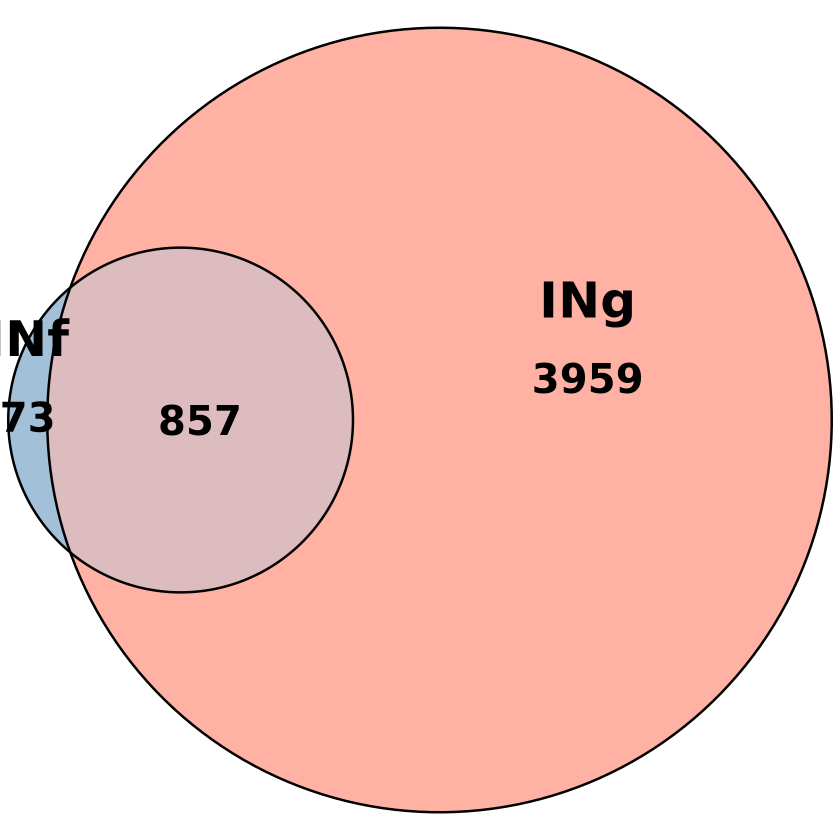

In [6]:
make_venn(NONO_INf_sigs, NONO_INg_sigs, "INf_INg_plots/NONO_INf_INg_eulerr.svg")

agg_record_1597779200 
                    2

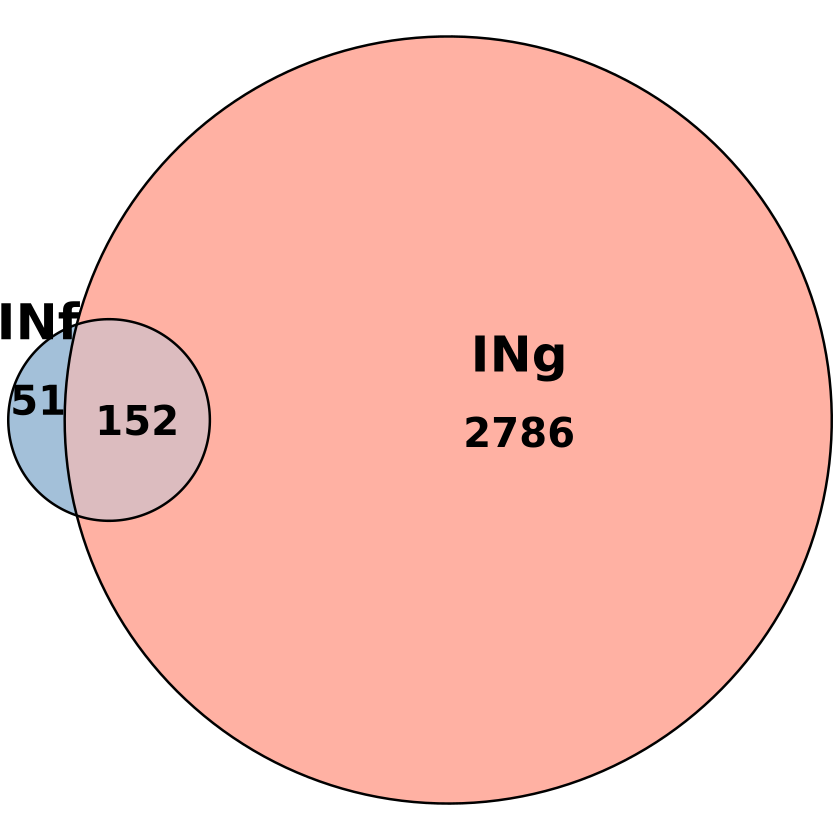

In [7]:
make_venn(DDX42_INf_sigs, DDX42_INg_sigs, "INf_INg_plots/DDX42_INf_INg_eulerr.svg")

agg_record_1456234262 
                    2

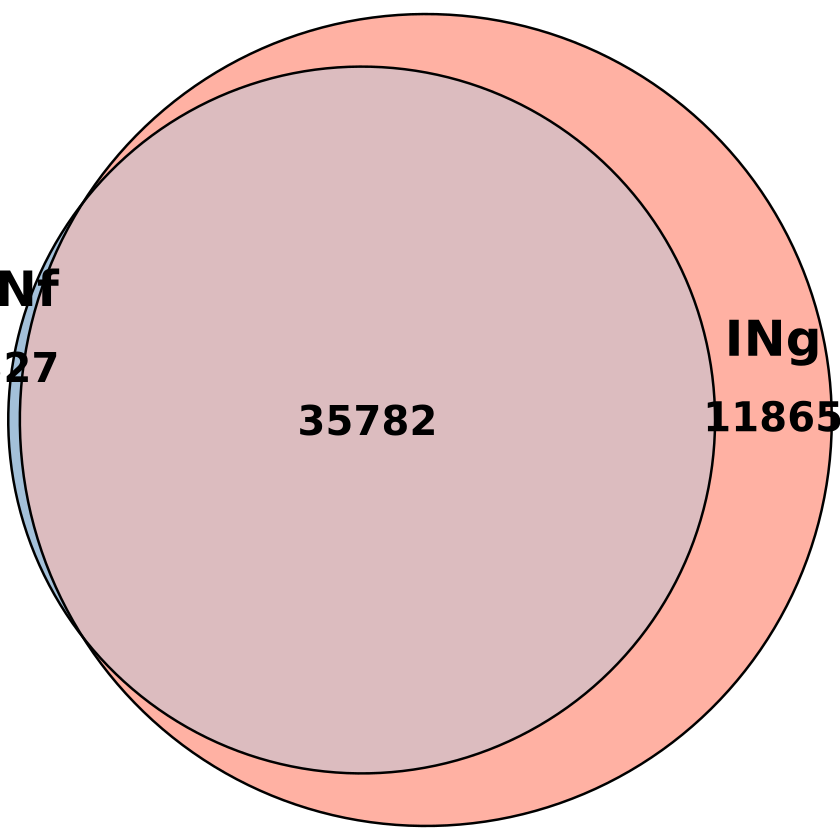

In [8]:
make_venn(PUF60_INf_sigs, PUF60_INg_sigs, "INf_INg_plots/PUF60_INf_INg_eulerr.svg")

# Histogram

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


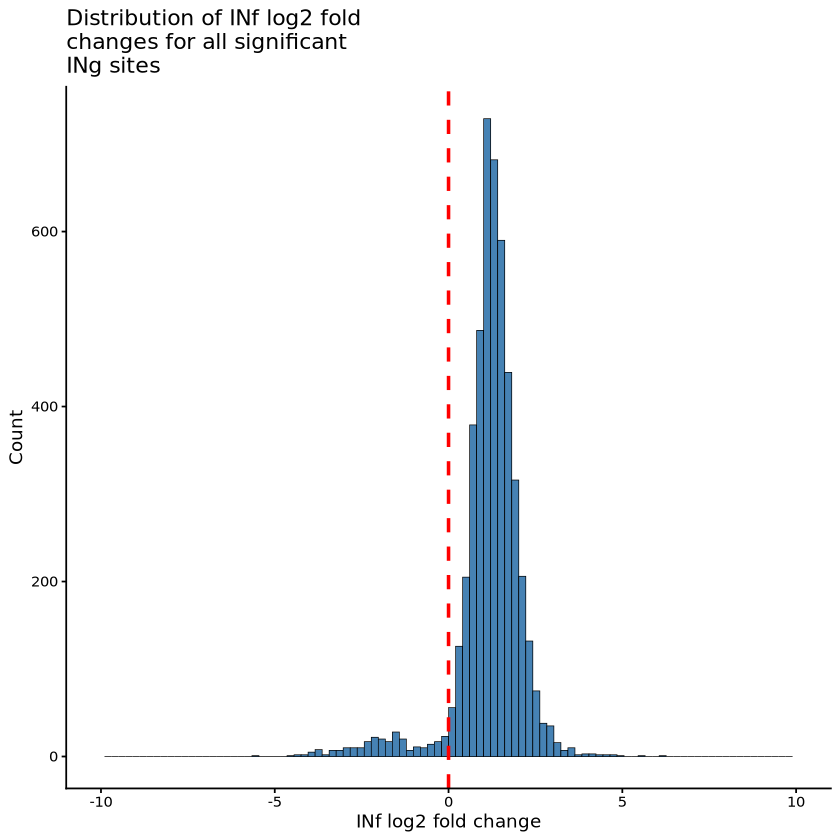

In [9]:
NONO_hist = make_hist(NONO_INf_all, NONO_INg_sigs)
ggsave("INf_INg_plots/NONO_histogram.svg", plot = NONO_hist, width = 5, height = 6, dpi = 300)
NONO_hist

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


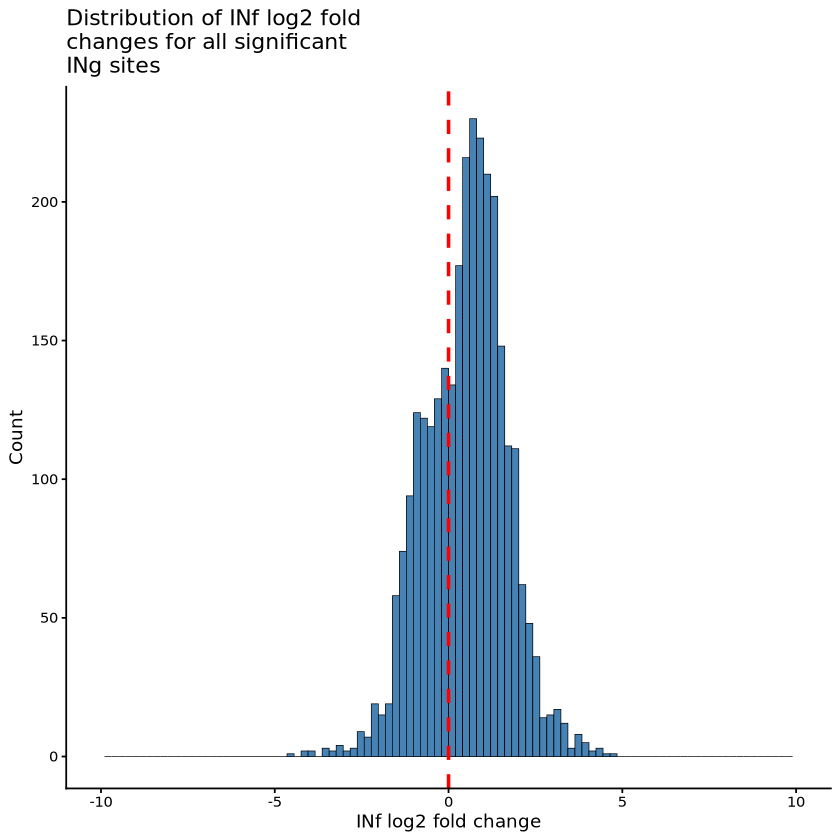

In [10]:
DDX42_hist = make_hist(DDX42_INf_all, DDX42_INg_sigs)
ggsave("INf_INg_plots/DDX42_histogram.svg", plot = DDX42_hist, width = 5, height = 6, dpi = 300)
DDX42_hist

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


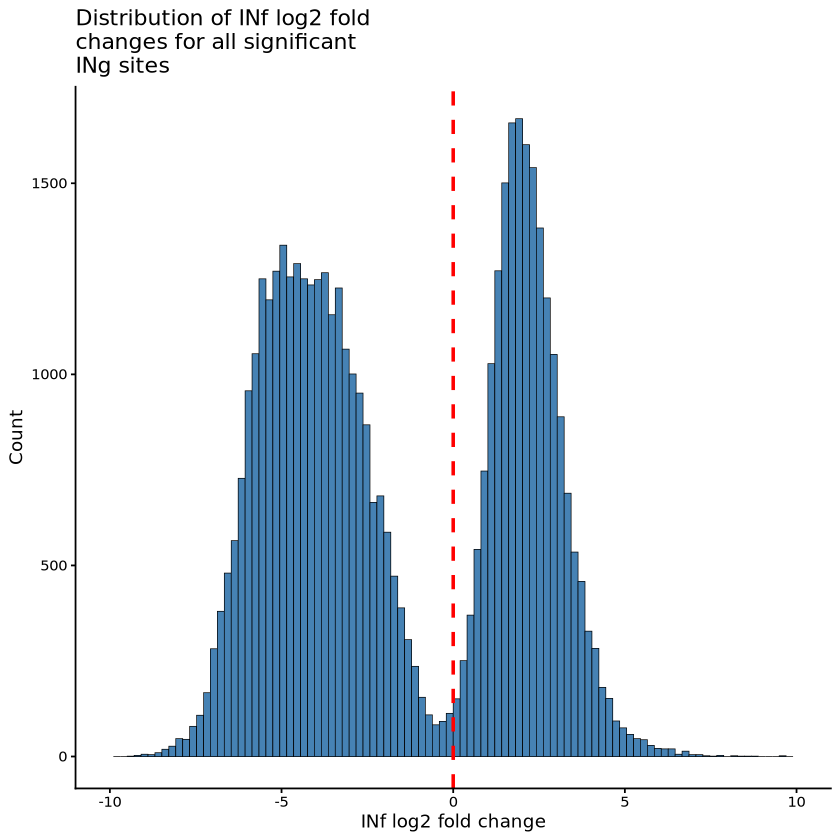

In [11]:
PUF60_hist = make_hist(PUF60_INf_all, PUF60_INg_sigs)
ggsave("INf_INg_plots/PUF60_histogram.svg", plot = PUF60_hist, width = 5, height = 6, dpi = 300)
PUF60_hist

# Scatterplot

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”


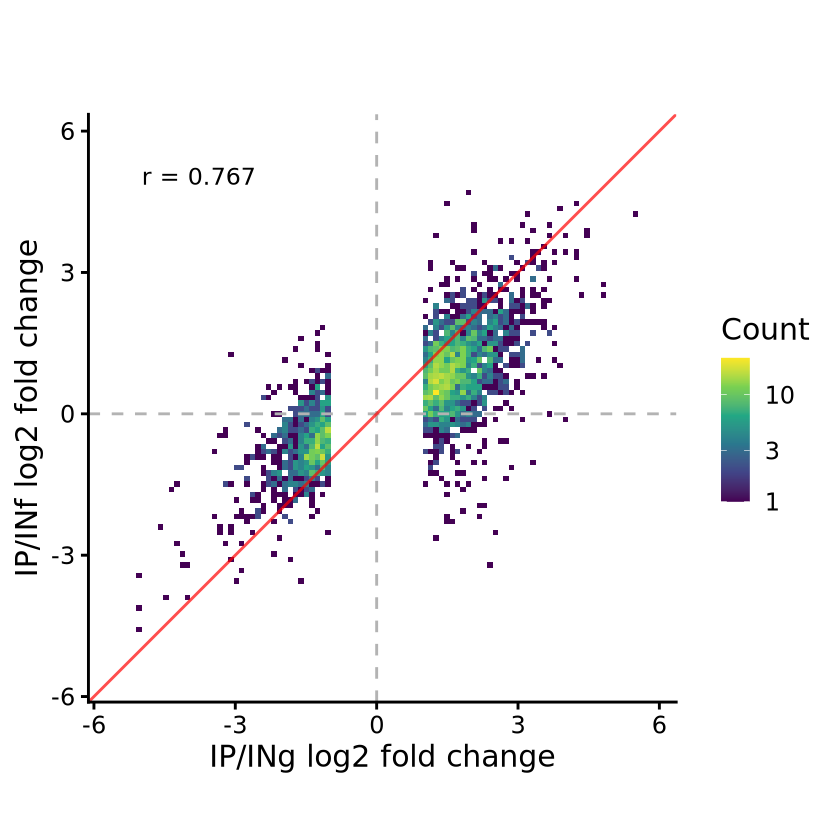

In [15]:
DDX42_scatter = make_scatter(DDX42_INf_all, DDX42_INf_sigs, DDX42_INg_all, DDX42_INg_sigs)
ggsave("INf_INg_plots/DDX42_scatterplot.svg", plot = DDX42_scatter, width = 6, height = 7, dpi = 300)
DDX42_scatter

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”


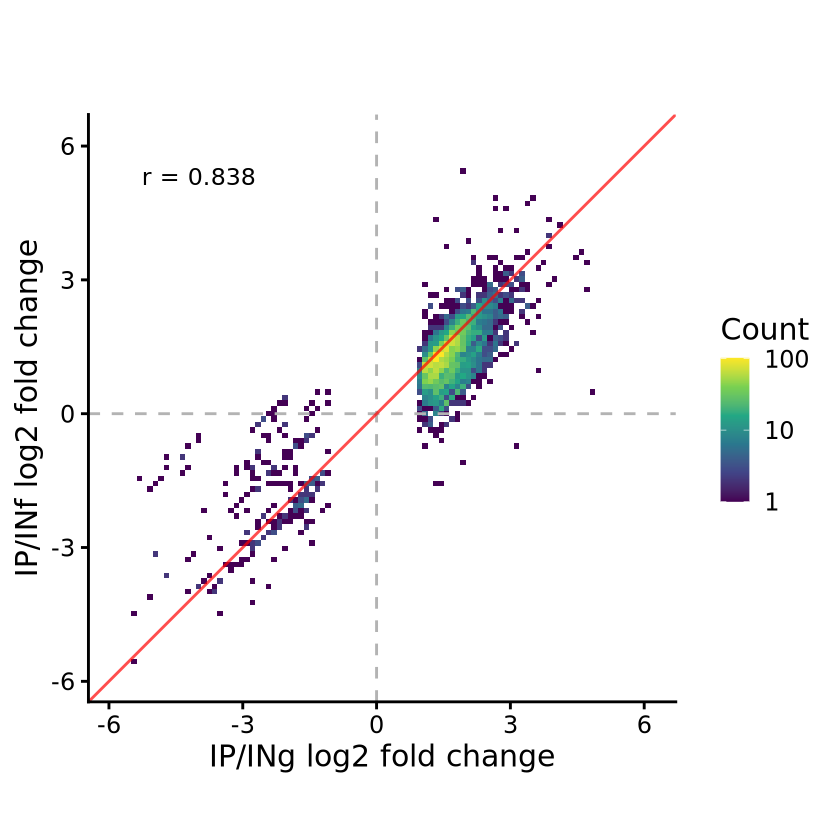

In [12]:
NONO_scatter = make_scatter(NONO_INf_all, NONO_INf_sigs, NONO_INg_all, NONO_INg_sigs)
ggsave("INf_INg_plots/NONO_scatterplot.svg", plot = NONO_scatter, width = 6, height = 7, dpi = 300)
NONO_scatter

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”


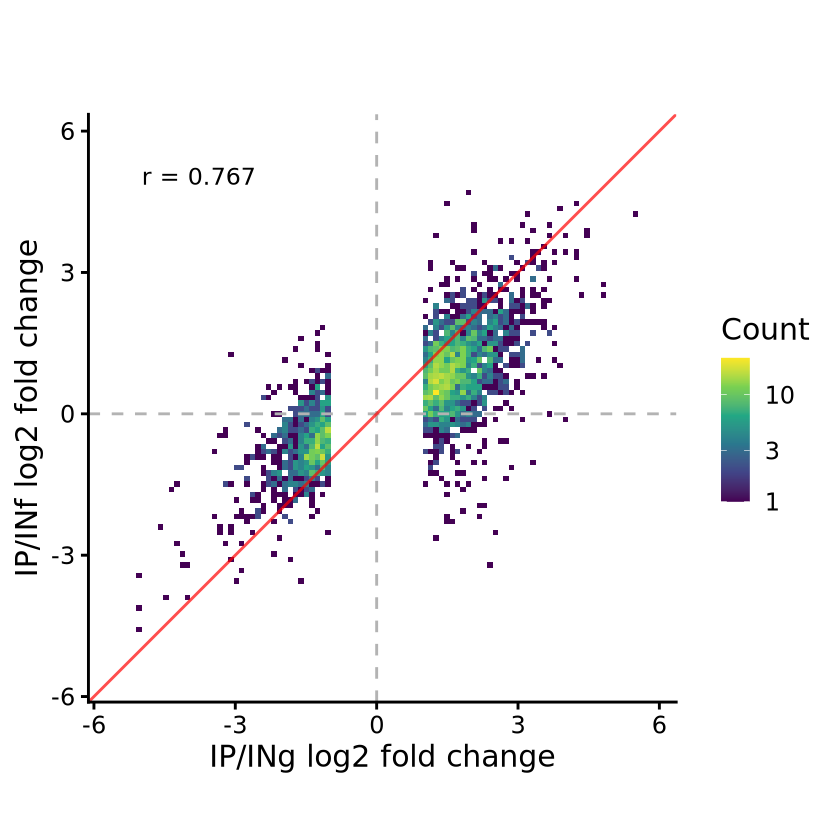

In [13]:
DDX42_scatter = make_scatter(DDX42_INf_all, DDX42_INf_sigs, DDX42_INg_all, DDX42_INg_sigs)
ggsave("INf_INg_plots/DDX42_scatterplot.svg", plot = DDX42_scatter, width = 6, height = 7, dpi = 300)
DDX42_scatter

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bin2d()`).”


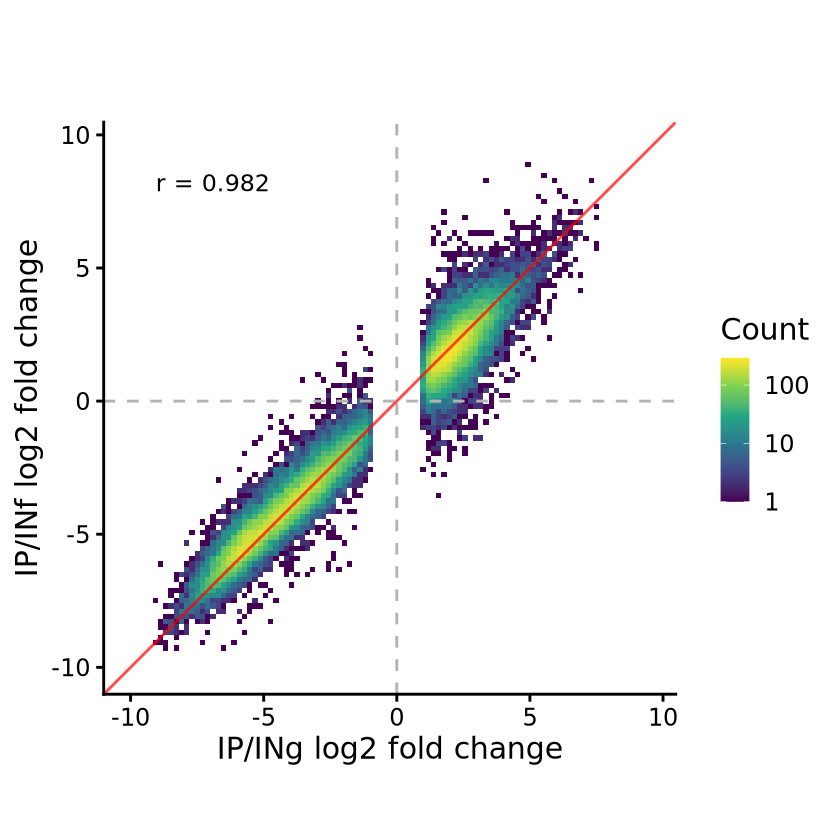

In [14]:
PUF60_scatter = make_scatter(PUF60_INf_all, PUF60_INf_sigs, PUF60_INg_all, PUF60_INg_sigs)
ggsave("INf_INg_plots/PUF60_scatterplot.svg", plot = PUF60_scatter, width = 6, height = 7, dpi = 300)
PUF60_scatter